# File 4 — Lifestyle Report

Professor-facing summary of the subject's **lifestyle**, built from File 3's outputs in
`results/lifestyle_construction/`. Replaces the old anomaly audit (ROC/PR/F1). **Descriptive only** —
no anomaly or health claims. Run File 3 (`03_lifestyle_construction.ipynb`) first.

## 1. Load lifestyle artifacts

In [1]:
import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = r"C:\Project\Apple Health Data"
LR = os.path.join(ROOT, "results", "lifestyle_construction")

emb = pd.read_parquet(os.path.join(LR, "day_embeddings.parquet"))
nodes = pd.read_csv(os.path.join(LR, "lifestyle_kg_nodes.csv"))
edges = pd.read_csv(os.path.join(LR, "lifestyle_kg_edges.csv"))
lmap = json.load(open(os.path.join(LR, "lifestyle_map.json")))
evalp = pd.read_csv(os.path.join(LR, "l1_proxy_eval.csv"))
emb["date"] = pd.to_datetime(emb["date"])
print(f"days: {len(emb):,} | lifestyle states: {len(nodes)} | KG edges: {len(edges)}")

days: 1,761 | lifestyle states: 3 | KG edges: 9


## 2. Lifestyle states — *what kind of days this person has*

Each state is a data-derived cluster of days; the name is a rule descriptor over its measured
attributes (median HR, weekday/workout fraction, wear, dominant month).

In [2]:
show = nodes[["state", "name", "n_days", "median_hr", "weekday_frac",
              "workout_day_frac", "median_wear_slots", "top_month"]]
print(show.to_string(index=False))
print("\nstate distribution (days):", lmap["state_distribution"])
print("subject priors:", {k: v for k, v in lmap.get("subject_priors", {}).items()
                          if not k.endswith("_detail")})

 state              name  n_days  median_hr  weekday_frac  workout_day_frac  median_wear_slots  top_month
     0   restful_weekday     683       85.8          0.73              0.07                 59          7
     1 high_tone_weekday     820       86.6          0.71              0.15                 58          3
     2 high_tone_weekday     258       87.5          0.71              0.14                 58          1

state distribution (days): {'high_tone_weekday': 1078, 'restful_weekday': 683}
subject priors: {'age_band': '40_49', 'sex': 'male', 'fitness_level': 'recreational', 'home_climate': 'temperate', 'occupation': 'unknown', 'heart_health': 'unknown', 'sleep': 'unknown', 'health_conditions': 'none'}


## 3. Weekly & seasonal rhythm

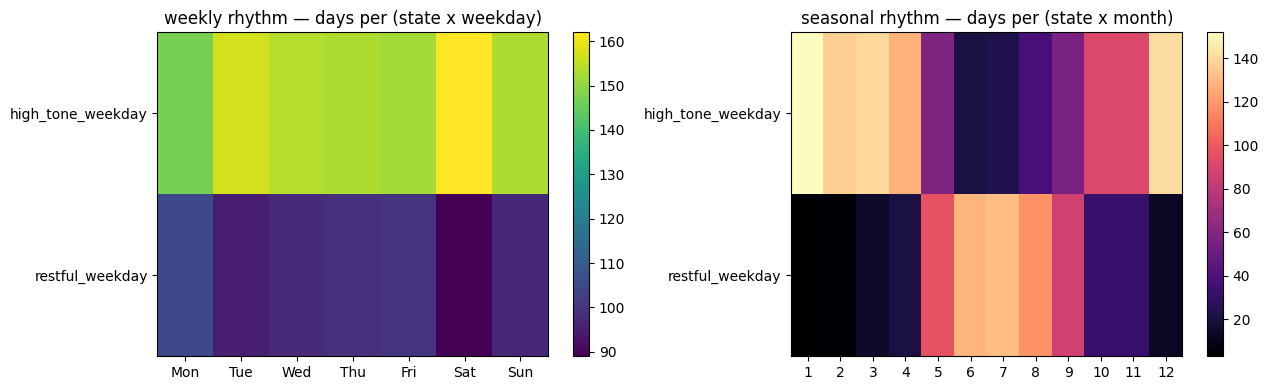

In [3]:
d = emb.copy()
d["dow"] = d["date"].dt.weekday
d["month"] = d["date"].dt.month
d["year"] = d["date"].dt.year

wk = d.groupby(["state_name", "dow"]).size().unstack(fill_value=0)
mo = d.groupby(["state_name", "month"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im0 = ax[0].imshow(wk.values, aspect="auto", cmap="viridis")
ax[0].set_yticks(range(len(wk.index))); ax[0].set_yticklabels(wk.index)
ax[0].set_xticks(range(7)); ax[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[0].set_title("weekly rhythm — days per (state x weekday)"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(mo.values, aspect="auto", cmap="magma")
ax[1].set_yticks(range(len(mo.index))); ax[1].set_yticklabels(mo.index)
ax[1].set_xticks(range(mo.shape[1])); ax[1].set_xticklabels(list(mo.columns))
ax[1].set_title("seasonal rhythm — days per (state x month)"); fig.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

## 4. State transitions (Lifestyle KG) & drift over the years

top day-to-day transitions:
             from                to  count
high_tone_weekday high_tone_weekday    557
  restful_weekday   restful_weekday    504
  restful_weekday high_tone_weekday    177
high_tone_weekday   restful_weekday    164
high_tone_weekday high_tone_weekday    158
high_tone_weekday high_tone_weekday     99
high_tone_weekday high_tone_weekday     85
high_tone_weekday   restful_weekday     15
  restful_weekday high_tone_weekday      1


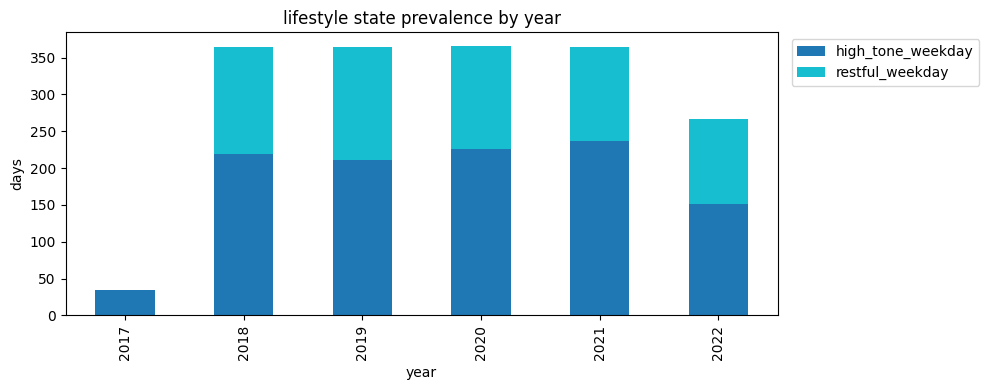

In [4]:
name_of = dict(zip(nodes["state"], nodes["name"]))
top = edges.head(10).copy()
top["from"] = top["src"].map(name_of)
top["to"] = top["dst"].map(name_of)
print("top day-to-day transitions:")
print(top[["from", "to", "count"]].to_string(index=False))

dr = d.groupby(["year", "state_name"]).size().unstack(fill_value=0)
dr.plot(kind="bar", stacked=True, figsize=(10, 4), colormap="tab10")
plt.title("lifestyle state prevalence by year"); plt.ylabel("days")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left"); plt.tight_layout(); plt.show()

## 5. Honest validation (no lifestyle ground truth)

The clusters are validated against **derivable** structure never used as a target. `month`/`season`
and `workout_day` are clean proxies; `weekday` is *dependent* (time-of-day is available to the encoder).
AMI = adjusted mutual information.

In [5]:
cols = ["arm", "k", "silhouette", "month_ami", "season_ami", "workout_day_ami", "weekday_ami_DEPENDENT"]
print(evalp[cols].to_string(index=False))
print("\nCaveats: single seed; non-workout activity_context is an LLM *inference* (the enriched-vs-raw"
      " ablation shows it is a useful one, not noise); the aggregate baseline still wins workout_day"
      " (a rare-event axis); the measured 'help' is on the seasonal axis.")

                 arm  k  silhouette  month_ami  season_ami  workout_day_ami  weekday_ami_DEPENDENT
transformer_enriched  3      0.2870     0.1674      0.1915           0.0084                -0.0004
  aggregate_baseline  3         NaN     0.0278      0.0225           0.3167                 0.0105
     transformer_raw  3      0.2956     0.1172      0.1357           0.0516                 0.0017

Caveats: single seed; non-workout activity_context is an LLM *inference* (the enriched-vs-raw ablation shows it is a useful one, not noise); the aggregate baseline still wins workout_day (a rare-event axis); the measured 'help' is on the seasonal axis.


## 6. Narrative summary

In [6]:
sp = lmap.get("subject_priors", {})
dom = max(lmap["state_distribution"], key=lmap["state_distribution"].get)
print(f"Subject: age_band={sp.get('age_band','?')}, fitness={sp.get('fitness_level','?')}, "
      f"climate={sp.get('home_climate','?')}.")
print(f"Across {lmap['n_days']:,} days the dominant lifestyle state is '{dom}'.")
print("Days separate mainly by seasonal tone and resting-HR level; the device is worn predominantly on"
      " weekdays. The LLM-enriched embedding recovers this seasonal rhythm better than raw features or a"
      " trivial daily aggregate. This is a descriptive lifestyle portrait, not an anomaly/health verdict.")

Subject: age_band=40_49, fitness=recreational, climate=temperate.
Across 1,761 days the dominant lifestyle state is 'high_tone_weekday'.
Days separate mainly by seasonal tone and resting-HR level; the device is worn predominantly on weekdays. The LLM-enriched embedding recovers this seasonal rhythm better than raw features or a trivial daily aggregate. This is a descriptive lifestyle portrait, not an anomaly/health verdict.


## File 4 output summary

A descriptive lifestyle report rendered from File 3's artifacts — lifestyle states, weekly & seasonal
rhythm, day-to-day transitions, yearly drift, and the honest enriched-vs-raw-vs-baseline validation.
No ROC/PR/F1 anomaly audit (the professor's request). The old audit notebook is archived in
`notebooks/_archive/04_audit_metrics.ipynb`.